In [2]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

def load_audio(file_path, sr=16000):
    """Загружает аудиофайл в моно с заданной частотой дискретизации."""
    signal, _ = librosa.load(file_path, sr=sr, mono=True)
    return signal

In [3]:
def plot_waveform(signal, sr, title="Raw Waveform"):
    plt.figure(figsize=(12, 3))
    librosa.display.waveshow(signal, sr=sr, alpha=0.8)
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

In [4]:
def plot_stft_magnitude(signal, sr, title="STFT Magnitude (Linear Freq)"):
    stft = np.abs(librosa.stft(signal))
    plt.figure(figsize=(12, 6))
    librosa.display.specshow(librosa.amplitude_to_db(stft, ref=np.max),
                             sr=sr, x_axis='time', y_axis='linear')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [5]:
def plot_mel_spectrogram(signal, sr, n_mels=128, title="Mel Spectrogram"):
    mel_spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=n_mels)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    plt.figure(figsize=(12, 6))
    librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [6]:
def plot_log_mel_spectrogram(signal, sr, n_mels=128, title="Log-Mel Spectrogram"):
    mel_spec = librosa.feature.melspectrogram(y=signal, sr=sr, n_mels=n_mels)
    mel_spec_db = librosa.power_to_db(mel_spec, ref=np.max)
    plt.figure(figsize=(12, 6))
    librosa.display.specshow(mel_spec_db, sr=sr, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [16]:
def plot_mfcc(signal, sr, n_mfcc=13, title="MFCC"):
    mfccs = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)
    plt.figure(figsize=(12, 6))
    librosa.display.specshow(mfccs, sr=sr, x_axis='time')
    plt.colorbar()
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [17]:
# Raw waveform – осциллограмма (громкость против времени).
#
# STFT magnitude – цветная карта, где по вертикали частоты от 0 до sr/2 Гц (линейная шкала).
#
# Mel spectrogram – такая же карта, но вертикальная шкала нелинейная (мел-частоты, плотнее внизу).
#
# Log-mel – выглядит так же, но контрастнее (благодаря логарифму).
#
# MFCC – обычно более «зернистое» изображение, горизонтальные полосы соответствуют разным коэффициентам.

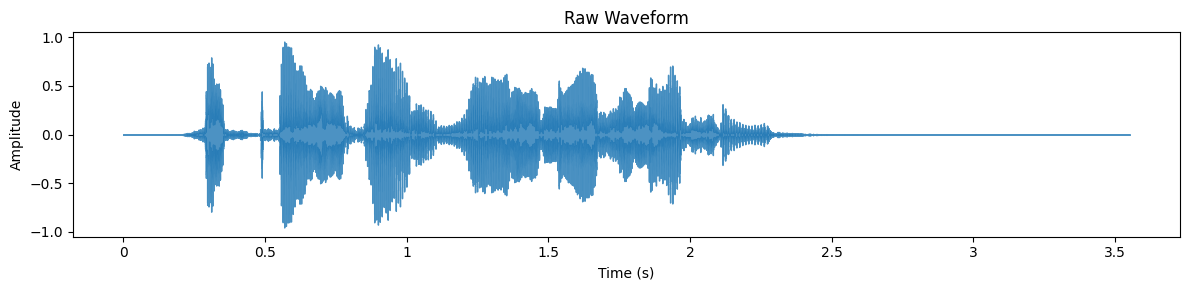

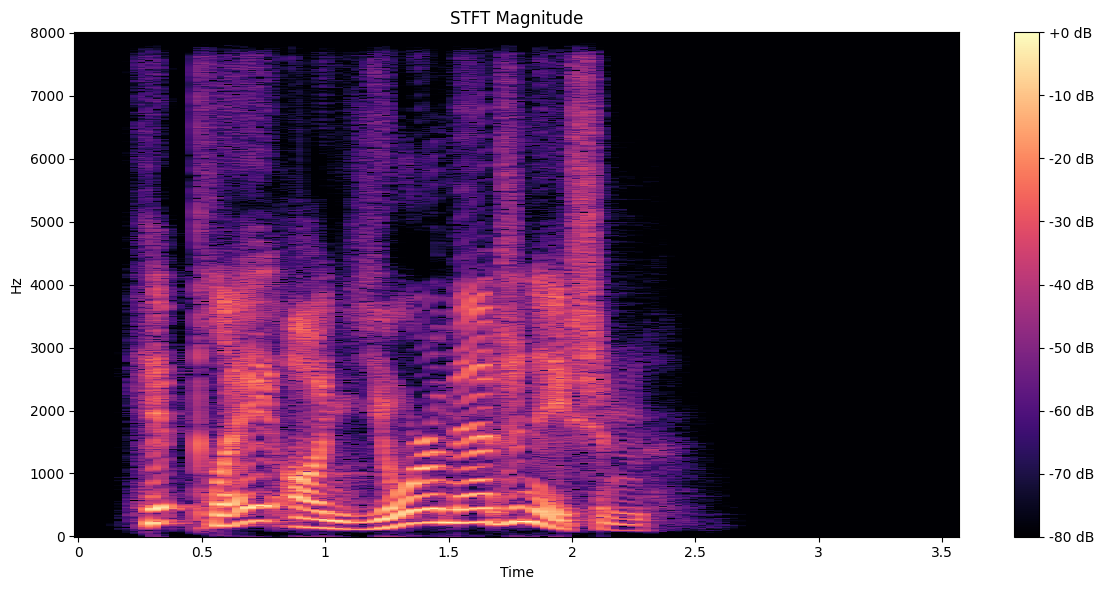

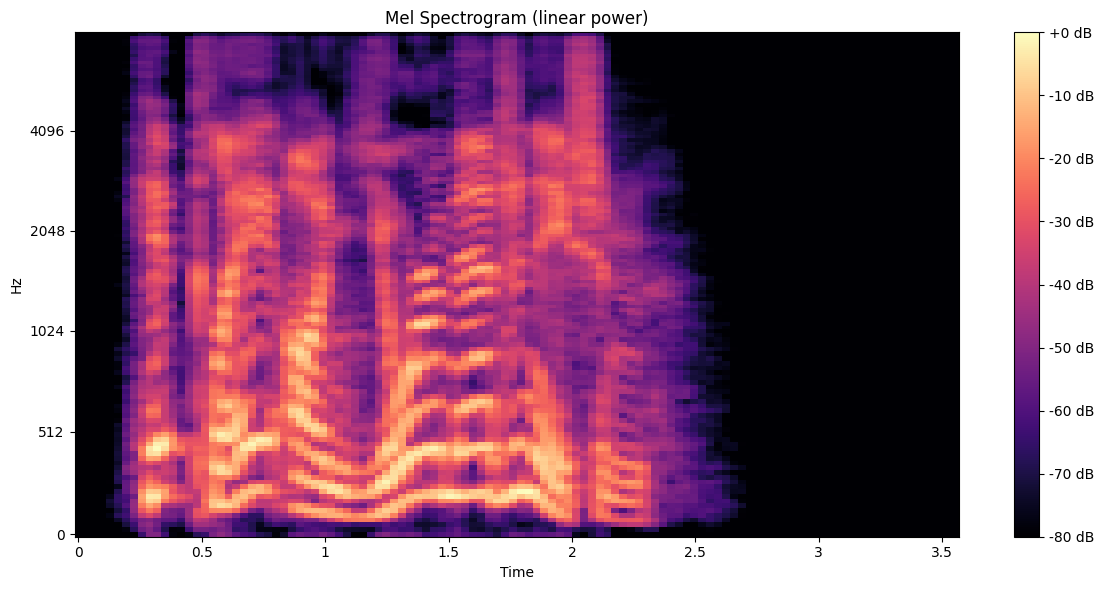

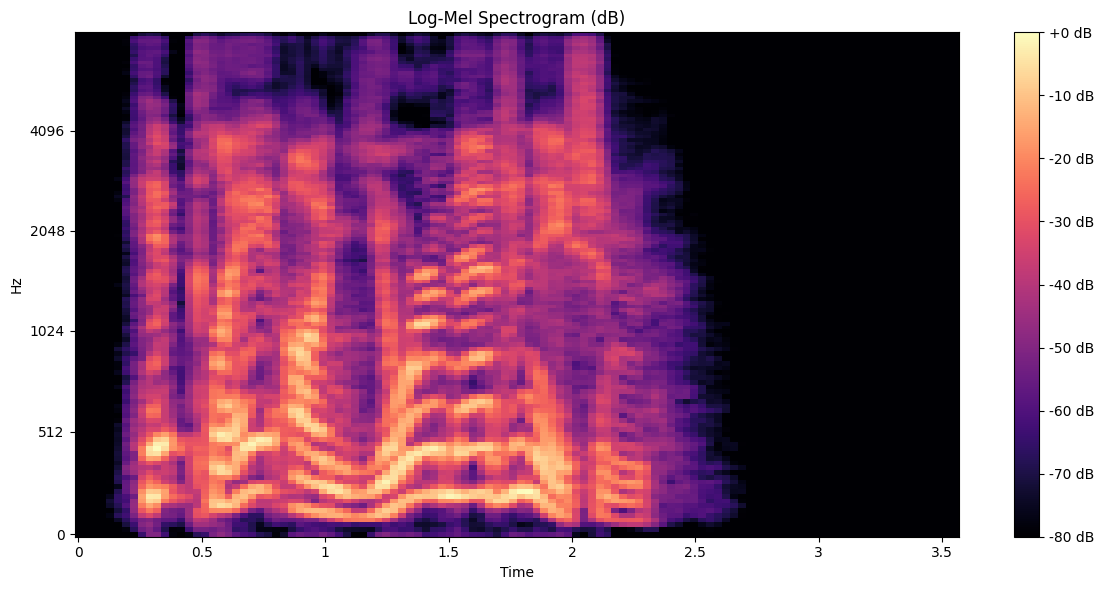

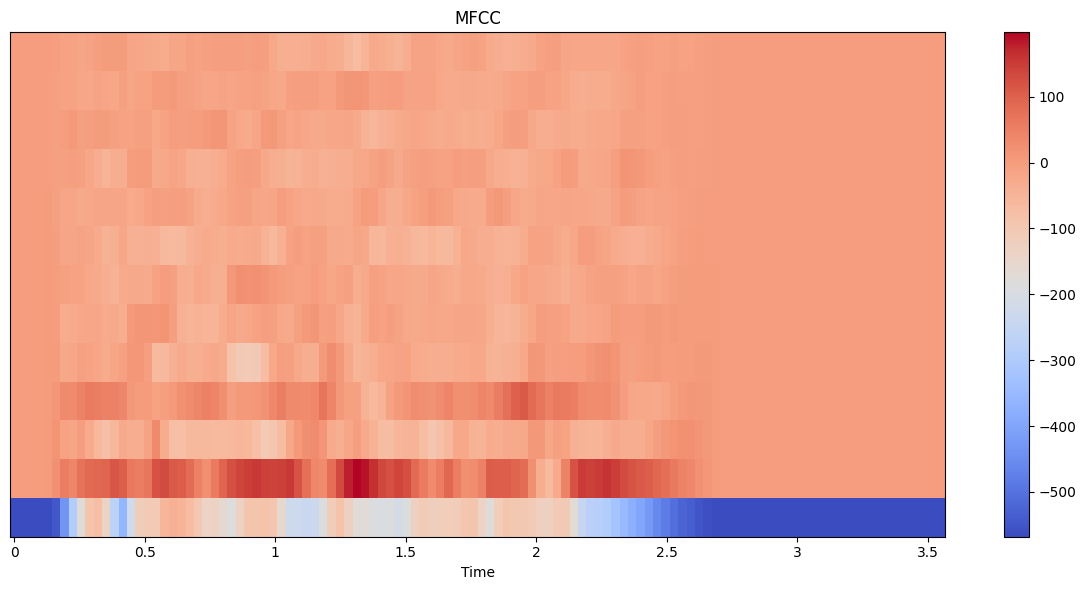

In [18]:
# Укажите путь к вашему MP3 файлу
audio_path = "examples/speech.mp3"

# Загрузка
sr = 16000
signal = load_audio(audio_path, sr=sr)

# Визуализации
plot_waveform(signal, sr, title="Raw Waveform")
plot_stft_magnitude(signal, sr, title="STFT Magnitude")
plot_mel_spectrogram(signal, sr, n_mels=128, title="Mel Spectrogram (linear power)")
plot_log_mel_spectrogram(signal, sr, n_mels=128, title="Log-Mel Spectrogram (dB)")
plot_mfcc(signal, sr, n_mfcc=13, title="MFCC")